In [1]:
from PBR import PBR
from KineticModel import KineticModel
from Reaction import Reaction
import numpy as np
from y_n import y_n
from upsilon_n import upsilon_n
from math import e
from sklearn.model_selection import ParameterGrid
import pandas as pd
from IPython.display import clear_output
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
parafins = [ 'methane', 'ethane', 'propane', 
             'butane', 'pentane', 'hexane', 
               'heptane', 'octane', 
             'nonane', 'decane', 'undecane', 'dodecane',
               'tridecane', 'tetradecane', 'pentadecane', 'hexadecane', 'heptadecane',
               'octadecane', 'nonadecane', 'eicosane', 'heneicosane', 'docosane',
               'tricosane', 'tetracosane', 'pentacosane',
               'hexacosane', 'heptacosane',
               'octacosane', 'nonacosane', 'triacontane',
             'hentriacontane', 'dotriacontane',
               'tritriacontane', 'tetratriacontane', 'pentatriacontane', 'hexatriacontane'
            ]

olefins = [ 'ethylene',
            'propene',
            '1-butene', '1-pentene', '1-hexene',
            '1-heptene', '1-octene', 
            '1-nonene', '1-decene',
            '1-undecene', '1-dodecene',
            '1-tridecene', '1-tetradecene', '1-pentadecene',
            '1-hexadecene', '1-heptadecene', '1-octadecene',
          ]

others = ['carbon monoxide', 'hydrogen', 'water', 'carbon dioxide']

In [3]:
def Mousavi(phi_220C):
    model_name = 'Mousavi'
    param_dict = {'k_ads': np.float64(1.397972209918762e-05),
                     'H_ads': np.float64(932.9790718460237),
                     'A_HCs': np.float64(955.0608601894231),
                     'E_HCs': np.float64(147203.9259840268),
                     'A_WGS': np.float64(2066275395.2988818),
                     'E_WGS': np.float64(164536.37699675243),
                     'a_WGS': np.float64(0.016649380568140318),
                     'b_WGS': np.float64(0.5269130869163346),
                     'E_C1' : np.float64(142601.814307),
                     'E_C2' : np.float64(153272.908181),
                 }

    bnds = {
        'k_ads': (0, None), # 1/Pa
        'H_ads': (0, None), # J/mol
        'A_HCs': (0, None), # mol/s/kg/Pa²
        'E_HCs': (0, None), # J/mol
        'A_WGS': (0, None), # mol/s/kg/Pa²
        'E_WGS': (0, None), # J/mol
        'a_WGS': (None, None),
        'b_WGS': (None, None),
        'E_C1' : (0, None),
        'E_C2' : (0, None),
    }

    model = KineticModel(model_name, params = param_dict, bnds = bnds)

    def rate_WGS(param_dict, T, P, x, F, K, eq_distance, R, data):
        P_CO = x['carbon monoxide']*P
        P_H2O = x['water']*P
        P_CO2 = x['carbon dioxide']*P
        P_H2 = x['hydrogen']*P

        A_WGS = param_dict['A_WGS']
        E_WGS = param_dict['E_WGS']
        a = param_dict['a_WGS']
        b = param_dict['b_WGS']

        K_WGS = 1.45e-2 * np.exp( 4.62e3 / T )
        k_WGS = A_WGS * np.exp ( - E_WGS / ( 8.314 * T ) )

        phi = phi_220C * ( ( 493 / T ) * np.exp( - ( E_WGS / R ) * ( 1/T - 1/493 ) ) ) ** (1/2)
        eff = np.tanh(phi)/phi

        rate_WGS = eff * ( k_WGS * P_CO**a * P_H2O**b ) * eq_distance
        return rate_WGS

    WGS = Reaction(
                     name = 'WGS',
                     stoic = {
                             'carbon monoxide': -1,
                             'water': -1,
                             'carbon dioxide': 1,
                             'hydrogen': 1,
                         },
                     base_component = 'carbon monoxide',
                     rate_function = rate_WGS,
                     rate_unit = 'mol/s/kg',
        )

    model.add_reaction(WGS)

    n_parafins = {}
    for i, parafin in enumerate(parafins):
        n = i + 1
        n_parafins[parafin] = n

    n_olefins = {}
    for i, olefin in enumerate(olefins):
        n = i + 1
        n_olefins[olefin] = n

    for parafin in n_parafins:
        n = n_parafins[parafin]
        def rate_n_para(param_dict, T, P, x, F, K, eq_distance, R, data, n = n):
            P_H2 = x['hydrogen']*P
            P_CO = x['carbon monoxide']*P

            k_ads = param_dict['k_ads']
            H_ads = param_dict['H_ads']
            A_HCs = param_dict['A_HCs']
            E_HCs = param_dict['E_HCs']

            if n == 1: E_HCs = param_dict['E_C1']
            if n == 2: E_HCs = param_dict['E_C2']

            F_H2 = x['hydrogen']*F
            F_CO = x['carbon monoxide']*F

            K_ads = k_ads * e**(-H_ads / (R * T))
            k_HCs = A_HCs * e**(-E_HCs / (R * T))

            phi = phi_220C * ( ( 493 / T ) * np.exp( - ( E_HCs / R ) * ( 1/T - 1/493 ) ) ) ** (1/2)
            eff = np.tanh(phi)/phi
            
            r     = eff * y_n(n, T) * upsilon_n(n, T) * k_HCs * P_H2**0.75 * P_CO / (1 + K_ads * P_CO)**2
            return r

        reaction = Reaction(
                     name = parafin,
                     stoic = {
                             'carbon monoxide': -n,
                             'hydrogen': -(2*n + 1),
                              parafin: 1,
                             'water': n,
                         },
                     base_component = parafin,
                     rate_function = rate_n_para,
                     rate_unit = 'mol/s/kg',
        )

        model.add_reaction(reaction)

    for olefin in n_olefins:
        n = n_olefins[olefin]
        def rate_n_ole(param_dict, T, P, x, F, K, eq_distance, R, data, n = n):
            P_H2 = x['hydrogen']*P
            P_CO = x['carbon monoxide']*P

            k_ads = param_dict['k_ads']
            H_ads = param_dict['H_ads']
            A_HCs = param_dict['A_HCs']
            E_HCs = param_dict['E_HCs']

            if n == 1: E_HCs = param_dict['E_C1']
            if n == 2: E_HCs = param_dict['E_C2']

            F_H2 = x['hydrogen']*F
            F_CO = x['carbon monoxide']*F

            K_ads = k_ads * e**(-H_ads / (R * T))
            k_HCs = A_HCs * e**(-E_HCs / (R * T))

            phi = phi_220C * ( ( 493 / T ) * np.exp( - ( E_HCs / R ) * ( 1/T - 1/493 ) ) ) ** (1/2)
            eff = np.tanh(phi)/phi
            
            r     = eff * y_n(n, T) * (1 - upsilon_n(n, T)) * k_HCs * P_H2**0.75 * P_CO / (1 + K_ads * P_CO)**2
            return r

        reaction = Reaction(
                     name = olefin,
                     stoic = {
                             'carbon monoxide': -n,
                             'hydrogen': -(2*n),
                              olefin: 1,
                             'water': n,
                         },
                     base_component = olefin,
                     rate_function = rate_n_ole,
                     rate_unit = 'mol/s/kg',
        )

        model.add_reaction(reaction)
    return model

In [4]:
def solve_ODEs(index, row):
    results = {}
    F0 = row['F_H2_in'] + row['F_CO_in']

    H2_CO = 2
    x_CO = 1 / ( 1 + H2_CO )
    x_H2 = 1 - x_CO

    # create reactor object
    T0 = (row['T_C'], 'C')
    x0 = {
                      'carbon monoxide': x_CO,
                      'hydrogen' : x_H2,
                  }
    reactor = PBR(T0 = T0, 
                  P0 = (row['P_bar'], 'bar'), 
                  x0 = x0, 
                  F0 = (F0, 'mol/s'),
                  isothermal = False, 
                  ergun = False,
                  WT = (row['W_kg'], 'kg'), 
                  W_steps = 1000,
                  U = (row['U'], 'W/m2/K'),
                  D = (45.1, 'mm'),
                  Dp = (4, 'mm'),
                  pellet_density = (2530, 'kg/m3'),
                  Ta = (190, 'C'),
                  liquid_phase = False,
                  units = 'SI',
                  solver_method = 'BDF',
                  rtol = 1e-5, atol = 1e-7,
                  calculate_equilibrium = False,
                  equilibrium_obj_fun_tolerance = 1e-12,
                  log = True,
                 )

    Mousavi_model = Mousavi(row['phi_220C'])
    reactor.add_model(Mousavi_model)
    reactor.solve()

    sol_df = reactor.sol_dfs['Mousavi']

    for component in parafins + olefins + others:
        results[f'Fout_{component}'] = sol_df.loc[
            (sol_df.W == sol_df.W.max()) & (sol_df.variable == component)].value.values[-1]

    Q_unit = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'Q')]['value units'].values[-1]
    results[f'Q ({Q_unit})'] = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'Q')].value.values[-1]
    
    T_unit = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'T')]['value units'].values[-1]
    results[f'max T ({T_unit})'] = sol_df.loc[(sol_df.variable == 'T')].value.max()
    return index, results

In [5]:
H2_CO_in = 2
x_H2_in = (H2_CO_in / ( 1 + H2_CO_in ))
x_CO_in = 1 - x_H2_in
MM = x_H2_in * 2 + x_CO_in * 28

m0 = 500 # kg/dia
m0 = m0 * 1000 / ( 24 * 60 * 60 )

F0 = m0 / MM

In [6]:
param_grid = {'T_C'        : [210], 
              'P_bar'      : [20],
              'F_H2_in'    : [F0 * x_H2_in],
              'F_CO_in'    : [F0 * x_CO_in],
              'U'   : np.linspace(0, 75, 200),
              'W_kg'       : [329.6],
              'phi_220C'   : [0.001, 2, 4, 10],
             }

parametric_data = pd.DataFrame(ParameterGrid(param_grid))

In [7]:
# if __name__ == "__main__":
# Determine number of workers (e.g., 4 or use os.cpu_count())
num_workers = 3

print(f"Starting parallel simulation with {num_workers} workers...")

# Prepare the list of tasks
tasks = [(idx, row) for idx, row in parametric_data.iterrows()]

# Execute in parallel
results_list = []
with ProcessPoolExecutor(max_workers=num_workers) as executor:
    # We use a wrapper or starmap-like approach
    futures = [executor.submit(solve_ODEs, *task) for task in tasks]
    
    for future in tqdm(futures, total=len(futures)):
        idx, res = future.result()
        # Update the dataframe with results
        for col, val in res.items():
            parametric_data.loc[idx, col] = val

# Save final results
parametric_data.to_pickle('parametric_data_PBRsim_U_req.pkl')
parametric_data.to_excel('parametric_data_PBRsim_U_req.ods')
print("Simulations complete.")

Starting parallel simulation with 3 workers...


100%|███████████████████████████████████████████████████████████████████████████████| 800/800 [1:12:38<00:00,  5.45s/it]


Simulations complete.


In [8]:
parametric_data = pd.read_pickle('parametric_data_PBRsim_U_req.pkl')

In [9]:
fig_path = '/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'

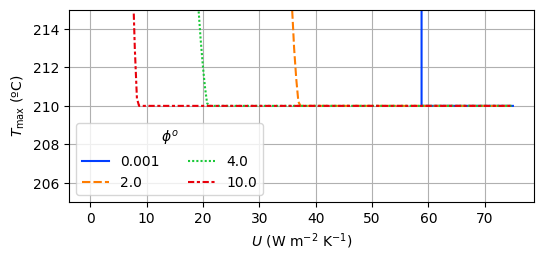

In [13]:
fig, ax = plt.subplots(figsize=(6,2.5))

parametric_data['max T (ºC)'] = parametric_data['max T (K)'] - 273.15

sns.lineplot(data = parametric_data,
            x = 'U', y = 'max T (ºC)', 
            hue = 'phi_220C', style = 'phi_220C', palette = 'bright', 
            ax = ax
            )
ax.grid('both')
# plt.xscale('log')
plt.ylim(205, 215)
# plt.xlim(0, 3000)
ax.legend(title = r'$\phi^o$', ncols = 2)
plt.xlabel(r'$U~\mathrm{(W~m^{-2}~K^{-1})}$')
plt.ylabel(r'$T_\mathrm{max}$ (ºC)')

fig_name = 'U_vs_Tmax.pdf'
plt.savefig(fig_path+fig_name, bbox_inches = 'tight')

plt.show()

In [11]:
parametric_data.columns

Index(['F_CO_in', 'F_H2_in', 'P_bar', 'T_C', 'U', 'W_kg', 'phi_220C',
       'Fout_methane', 'Fout_ethane', 'Fout_propane', 'Fout_butane',
       'Fout_pentane', 'Fout_hexane', 'Fout_heptane', 'Fout_octane',
       'Fout_nonane', 'Fout_decane', 'Fout_undecane', 'Fout_dodecane',
       'Fout_tridecane', 'Fout_tetradecane', 'Fout_pentadecane',
       'Fout_hexadecane', 'Fout_heptadecane', 'Fout_octadecane',
       'Fout_nonadecane', 'Fout_eicosane', 'Fout_heneicosane', 'Fout_docosane',
       'Fout_tricosane', 'Fout_tetracosane', 'Fout_pentacosane',
       'Fout_hexacosane', 'Fout_heptacosane', 'Fout_octacosane',
       'Fout_nonacosane', 'Fout_triacontane', 'Fout_hentriacontane',
       'Fout_dotriacontane', 'Fout_tritriacontane', 'Fout_tetratriacontane',
       'Fout_pentatriacontane', 'Fout_hexatriacontane', 'Fout_ethylene',
       'Fout_propene', 'Fout_1-butene', 'Fout_1-pentene', 'Fout_1-hexene',
       'Fout_1-heptene', 'Fout_1-octene', 'Fout_1-nonene', 'Fout_1-decene',
       'Fou

In [12]:
parametric_data.loc[(parametric_data.phi_220C == 2) & (parametric_data['max T (ºC)'] < 270)]

,F_CO_in,F_H2_in,P_bar,T_C,U,W_kg,phi_220C,Fout_methane,Fout_ethane,Fout_propane,...,Fout_1-hexadecene,Fout_1-heptadecene,Fout_1-octadecene,Fout_carbon monoxide,Fout_hydrogen,Fout_water,Fout_carbon dioxide,Q (W),max T (K),max T (ºC)
373,0.180845,0.36169,20,210,35.050251,329.6,2.0,0.004867,0.000173,0.001249,...,0.000031,0.000020,0.000013,0.061777,0.115050,0.116775,0.001146,-18759.399615,498.111883,224.961883
377,0.180845,0.36169,20,210,35.427136,329.6,2.0,0.003879,0.000131,0.001005,...,0.000030,0.000020,0.000013,0.076567,0.145816,0.102591,0.000844,-16444.134521,491.609443,218.459443
381,0.180845,0.36169,20,210,35.804020,329.6,2.0,0.003372,0.000110,0.000877,...,0.000029,0.000019,0.000013,0.085141,0.163622,0.094319,0.000692,-15107.630948,488.318446,215.168446
385,0.180845,0.36169,20,210,36.180905,329.6,2.0,0.003040,0.000097,0.000793,...,0.000028,0.000019,0.000012,0.091165,0.176140,0.088477,0.000602,-14170.795264,486.138199,212.988199
389,0.180845,0.36169,20,210,36.557789,329.6,2.0,0.002801,0.000088,0.000733,...,0.000027,0.000018,0.000012,0.095728,0.185656,0.084017,0.000550,-13461.431197,484.555302,211.405302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
781,0.180845,0.36169,20,210,73.492462,329.6,2.0,0.000872,0.000021,0.000232,...,0.000016,0.000011,0.000008,0.142617,0.282850,0.038008,0.000110,-6268.360822,483.150000,210.000000
785,0.180845,0.36169,20,210,73.869347,329.6,2.0,0.000869,0.000021,0.000231,...,0.000016,0.000011,0.000008,0.142695,0.283011,0.037931,0.000110,-6256.590960,483.150000,210.000000
789,0.180845,0.36169,20,210,74.246231,329.6,2.0,0.000867,0.000021,0.000230,...,0.000016,0.000011,0.000007,0.142772,0.283170,0.037855,0.000109,-6245.004593,483.150000,210.000000
793,0.180845,0.36169,20,210,74.623116,329.6,2.0,0.000864,0.000021,0.000230,...,0.000015,0.000011,0.000007,0.142847,0.283325,0.037781,0.000109,-6233.597656,483.150000,210.000000
